<a href="https://colab.research.google.com/github/Leo05-u/EMSC2010_A3-Project-Notebook-Repository/blob/main/EMSC2010_A3_Project_Notebook_%26_Repository_u7447903.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A3:** Project Notebook & Repository

**Student:** Leo Moore (u7447903)
<br><br>

**Problem framing and scope**

– Clear, well-defined question; scope is appropriate and well justified

<br>

**Methodological reasoning**

– Methods are appropriate, clearly explained, and explicitly linked to the research question
<br><br>

**Use and understanding of data**

– Data are loaded, cleaned, and handled sensibly; assumptions and choices are clearly acknowledged
<br><br>

**Interpretation and critical thinking**

– Results are interpreted thoughtfully, with discussion of limitations and uncertainty
<br><br>

**Reproducibility and archiving**

– Notebook runs as submitted; repository is well organised; required data files are accessible; instructions are clear

**Aim:** To investigate whether the Australian population has declining over the past decade and whether this pattern is likely to continue for the forseeable future.

**Dataset selection & cleaning**

Original data source:

 https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQByZJS4Cp7JS5tvc3dwtmM7AbzltfYk_iXXTVLNupq2W1c?e=Fuwv62

Clean data used for the calculations within this notebook:

 https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQBHRjtq0kTeQIHrPhKs4CuhAe9TkeEBmuRkty7g4z5emvY?e=5LvksX

**Introduction:**
Birth and death rates are essential for understanding a population. The population size for the purposes of this notebook is defined as a group of individuals living in a country. The Contry of interest is Australia, and the aim of this project is to investigate whether the Australian population is declining.

In [ ]:
#IMPORTING THE LIBRARIES
import pandas as pd #for data importing
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

#Note to self: delete any imports that don't get utilised

In [ ]:
# Load the cleaned coral cover dataset from the Excel file

spreadsheet_name = 'Monthly_B&DRates_ByYear.xlsx'
worksheet_name = 'Sheet1'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [ ]:
#showing the dataframe
df.head()

,Year,Month,Births,Deaths
0,2015,January,6001,4698
1,2015,February,7441,3926
2,2015,March,8612,3718
3,2015,April,8079,3846
4,2015,May,12551,4757


In [ ]:
#Averaging the yearly birth and death rates

average_yearly_births = df.groupby('Year')['Births'].mean()
display(average_yearly_births)

average_yearly_deaths = df.groupby('Year')['Deaths'].mean()
display(average_yearly_deaths)

,Births
Year,
2015,8242.666667
2016,7901.166667
2017,7735.416667
2018,9028.583333
2019,8127.250000
2020,7852.416667
2021,8330.833333
2022,8028.333333
2023,7551.000000


,Deaths
Year,
2015,4420.500000
2016,4437.083333
2017,4348.583333
2018,4434.916667
2019,4637.000000
2020,4338.000000
2021,4661.916667
2022,5191.583333
2023,4905.833333


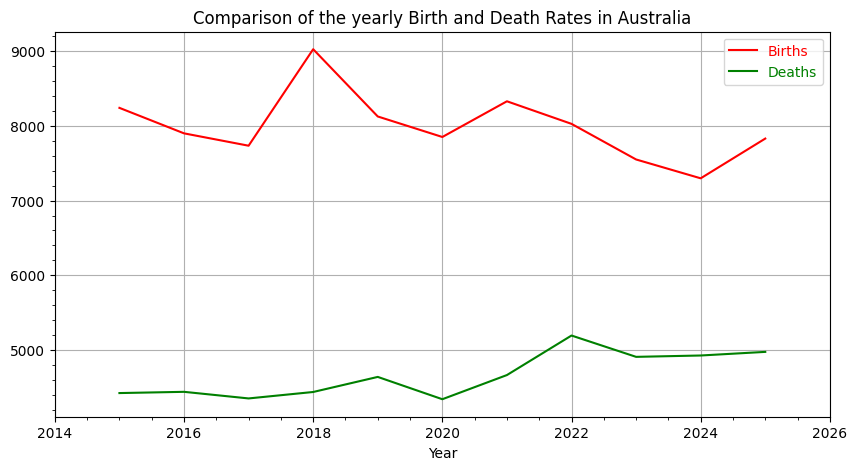

In [ ]:
#Generating the rough plot for the yearly birth and death rates

fig, ax = plt.subplots(figsize=(10, 5)) #size of plot
ax.plot(average_yearly_births.index, average_yearly_births,'r') #Births per year
ax.plot(average_yearly_deaths.index, average_yearly_deaths,'g') #Deaths per year
ax.set_xlabel('Year') #text for the x-axis label
ax.set_title('Comparison of the yearly Birth and Death Rates in Australia') #text for the title
legend = ax.legend(['Births','Deaths'], labelcolor='linecolor') #text for the legend
ax.grid() #show the gridlines
ax.set_xlim([2014,2026]) #interval for the x-axis
ax.minorticks_on() #show the minor ticks

Bootstrapping the data measures the amount of uncertainty exists in the birth and death rate data. This produces a distribution of possible outcomes where if most bootstrap samples show deaths exceeding births, it suggests natural decline and vice versa.

In [ ]:
BS_Births = np.random.choice(df['Births'], size=len(df['Births']), replace=True) #find the mean of the X array
print(np.mean(BS_Births))

BS_Deaths = np.random.choice(df['Deaths'], size=len(df['Deaths']), replace=True) #find the mean of the X array
print(np.mean(BS_Deaths))

7954.325757575758
4659.363636363636


In [ ]:
BS2_Births = np.random.choice(df['Births'], size=(len(df['Births']), 1000), replace=True) #Generate 1000 columns of Bootstraps
print(np.shape(BS2_Births))

BS2_Deaths = np.random.choice(df['Deaths'], size=(len(df['Deaths']), 1000), replace=True) #Generate 1000 columns of Bootstraps
print(np.shape(BS2_Deaths))

(132, 1000)
(132, 1000)


(1000,)
(1000,)


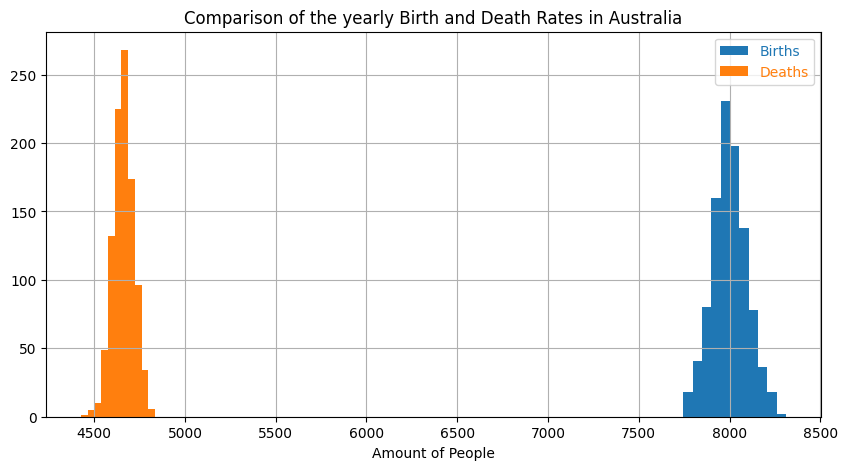

In [ ]:
bar_B = np.mean(BS2_Births, axis=0) #average of each column of the bootstrap for births
print(np.shape(bar_B))

bar_D = np.mean(BS2_Deaths, axis=0) #average of each column of the bootstrap for deaths
print(np.shape(bar_D))

# Creating a histogram for the bootstrap
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(bar_B, bins=11, label='Births') #11 used because its the amount of years of the dataset
ax.hist(bar_D, bins=11, label='Deaths') #11 used because its the amount of years of the dataset

ax.set_xlabel('Amount of People') #text for the x-axis label
ax.set_title('Comparison of the yearly Birth and Death Rates in Australia') #text for the title
ax.legend(labelcolor='linecolor') #text for the legend
ax.grid() #show the gridlines
plt.show()

In [ ]:
#Finding the confidence interval for the birth and death rates

CI_B = np.percentile(bar_B, [2.5, 97.5]) #95% confidence interval of births
print(CI_B)

CI_D = np.percentile(bar_D, [2.5, 97.5]) #95% confidence interval of deaths
print(CI_D)

[7815.67045455 8193.96306818]
[4546.36893939 4773.0967803 ]


The bootstrap shows that birth rates are far exceeding death rates throught the random sampling. This indicates that it is highly likely that there are more births than deaths during any given year.

Polynomial regression to the trends of birth and death rates  between 2015 and 2025. This is used to disply any trends in the data. Polynomial regression was used to show whether the long‑term trajectory of birth and death rates is bending upward or downward.

In [ ]:
!pip install bambi # Install bambi
import bambi as bmb # Use bambi, aliased as bmb
import arviz as az #for analysis of Bayesian models

data_B = pd.DataFrame({"x": df['Year'], "y": df['Births']}) #put the data into a dataframe with variable names "x" and "y".
model_B = bmb.Model("y ~ x", data_B) #setup the first-order polynomial model
idata_B = model_B.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

data_D = pd.DataFrame({"a": df['Year'], "b": df['Deaths']}) #put the data into a dataframe with variable names "a" and "b".
model_D = bmb.Model("b ~ a", data_D) #setup the first-order polynomial model
idata_D = model_D.fit(draws=2000, tune=2000, chains=8, progressbar=False) #sample the posteriors

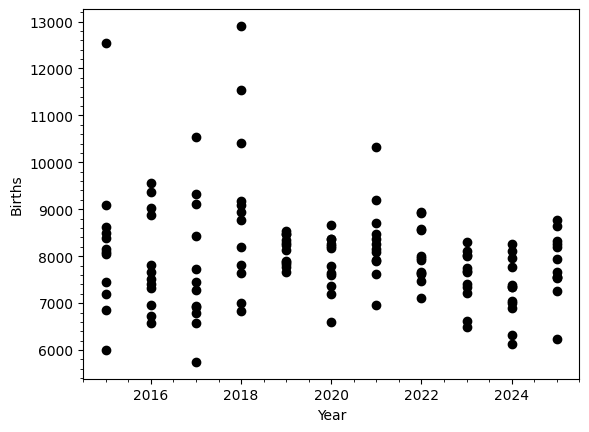

In [ ]:
# Initial plot of birth rates over years
plt.plot(df['Year'], df['Births'],'ok')
plt.xlabel('Year')
plt.ylabel('Births')
plt.minorticks_on()

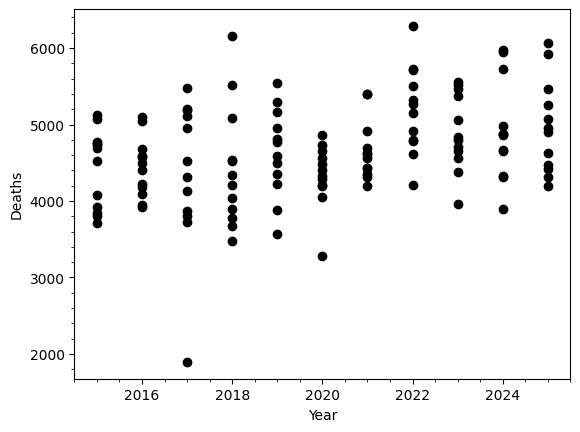

In [ ]:
# Initial plot of death rates over years
plt.plot(df['Year'], df['Deaths'],'ok')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.minorticks_on()

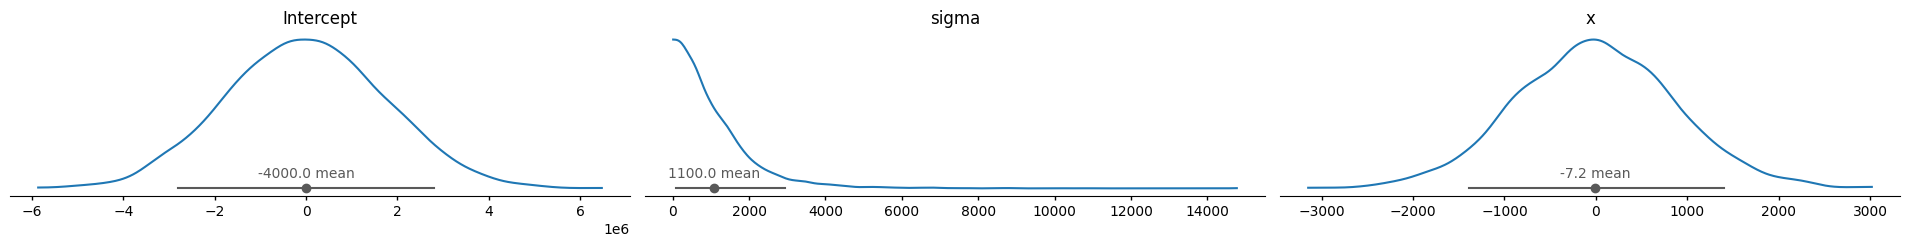

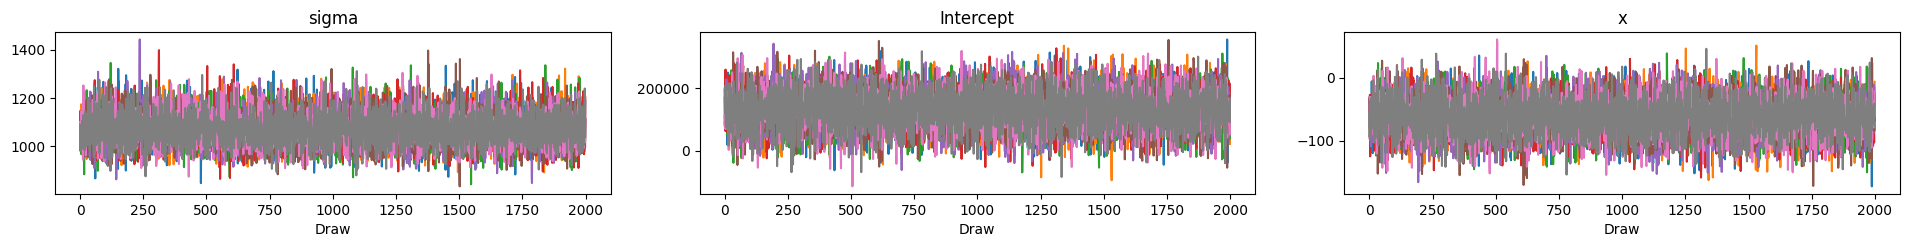

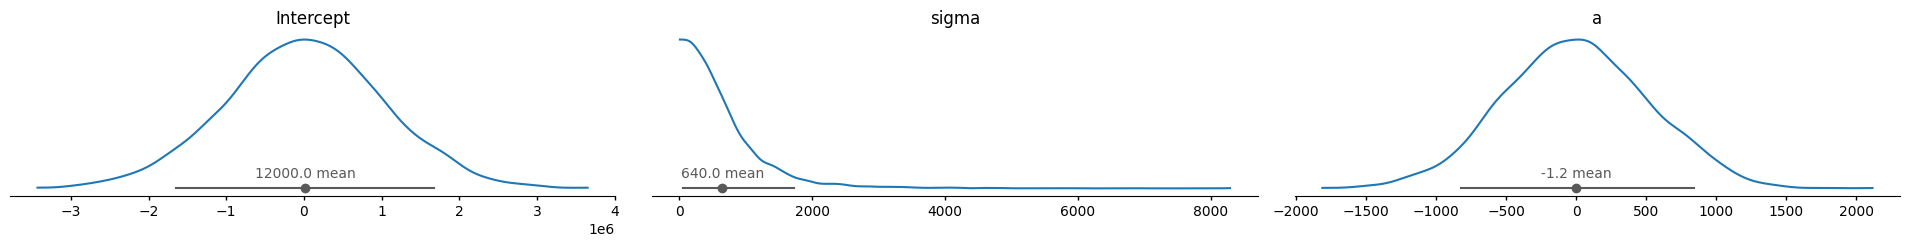

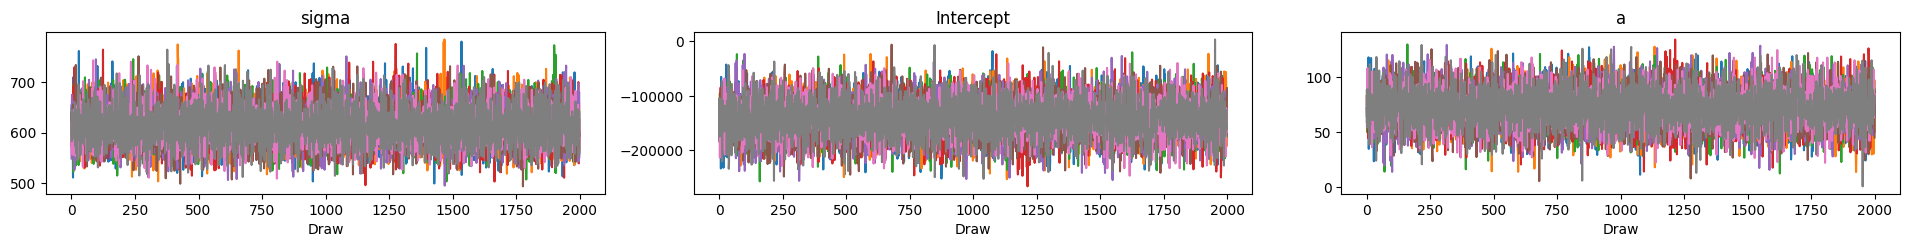

In [ ]:
# Modelling the priors for the birth and death rates
model_B.plot_priors()
plt.tight_layout()
plt.show()
az.plot_trace(idata_B);
plt.tight_layout() #this spaces the plots out so that they don't overlap

model_D.plot_priors()
plt.tight_layout()
plt.show()
az.plot_trace(idata_D);
plt.tight_layout() #this spaces the plots out so that they don't overlap

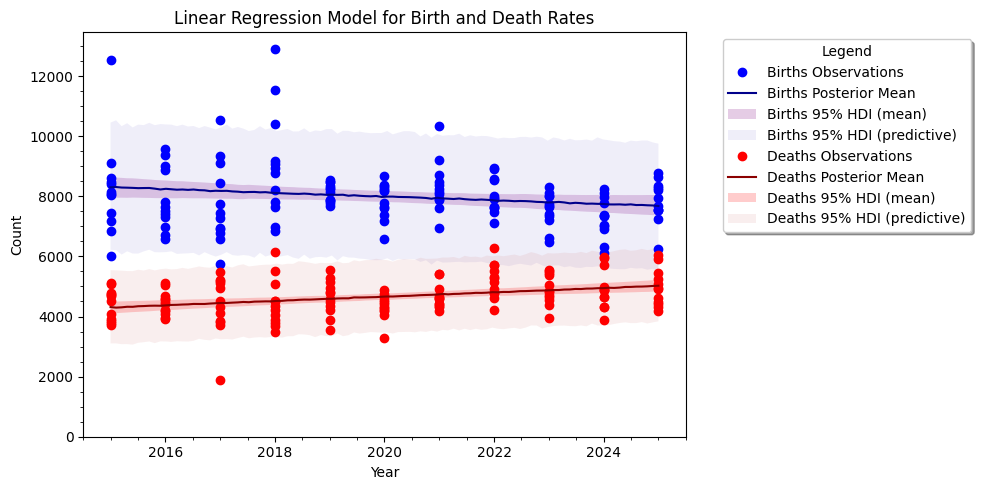

In [ ]:
from matplotlib.ticker import MaxNLocator

# Define prediction range from the min to max year in the dataset
min_year = int(df['Year'].min())
max_year = int(df['Year'].max())
x_range_years = np.linspace(min_year, max_year, 100)

# Create new dataframes for prediction for births and deaths
new_data_births = pd.DataFrame({"x": x_range_years})
new_data_deaths = pd.DataFrame({"a": x_range_years})

# Predict the distribution of regression lines for births
idata_predictions_births_params = model_B.predict(idata_B, data=new_data_births, kind='response_params', inplace=False)
idata_predictions_births_response = model_B.predict(idata_B, data=new_data_births, kind='response', inplace=False)

# Make random draws from the posterior for births
y_births_mean_draws = idata_predictions_births_params.posterior["mu"].values.reshape(-1, len(x_range_years))
y_births_pps_draws = idata_predictions_births_response.posterior_predictive["y"].values.reshape(-1, len(x_range_years))

# Compute the mean and HDI of the posterior predictive distribution for births
posterior_mean_births = y_births_pps_draws.mean(axis=0)
hdi_mean_births = az.hdi(y_births_mean_draws, 0.95, axis=0)
hdi_pps_births = az.hdi(y_births_pps_draws, 0.95, axis=0)

# Predict the distribution of regression lines for deaths
idata_predictions_deaths_params = model_D.predict(idata_D, data=new_data_deaths, kind='response_params', inplace=False)
idata_predictions_deaths_response = model_D.predict(idata_D, data=new_data_deaths, kind='response', inplace=False)

# Make random draws from the posterior for deaths
y_deaths_mean_draws = idata_predictions_deaths_params.posterior["mu"].values.reshape(-1, len(x_range_years))
y_deaths_pps_draws = idata_predictions_deaths_response.posterior_predictive["b"].values.reshape(-1, len(x_range_years))

# Compute the mean and HDI of the posterior predictive distribution for deaths
posterior_mean_deaths = y_deaths_pps_draws.mean(axis=0)
hdi_mean_deaths = az.hdi(y_deaths_mean_draws, 0.95, axis=0)
hdi_pps_deaths = az.hdi(y_deaths_pps_draws, 0.95, axis=0)

# PLOT BOTH POSTERIOR FOR REGRESSION LINES AND THE OBSERVATIONS
plt.figure(figsize=(10, 5))

# Births Plot
plt.plot(df['Year'], df['Births'], 'o', color='blue', label='Births Observations')
plt.plot(x_range_years, posterior_mean_births, color="darkblue", label='Births Posterior Mean')
plt.fill_between(
    x_range_years,
    hdi_mean_births[:, 0],
    hdi_mean_births[:, 1],
    alpha=0.2,
    color="purple",
    label='Births 95% HDI (mean)',
    edgecolor=None
)
plt.fill_between(
    x_range_years,
    hdi_pps_births[:, 0],
    hdi_pps_births[:, 1],
    alpha=0.1,
    color="slateblue",
    label='Births 95% HDI (predictive)',
    edgecolor=None
)

# Deaths Plot
plt.plot(df['Year'], df['Deaths'], 'o', color='red', label='Deaths Observations')
plt.plot(x_range_years, posterior_mean_deaths, color="darkred", label='Deaths Posterior Mean')
plt.fill_between(
    x_range_years,
    hdi_mean_deaths[:, 0],
    hdi_mean_deaths[:, 1],
    alpha=0.2,
    color="red",
    label='Deaths 95% HDI (mean)',
    edgecolor=None
)
plt.fill_between(
    x_range_years,
    hdi_pps_deaths[:, 0],
    hdi_pps_deaths[:, 1],
    alpha=0.1,
    color="indianred",
    label='Deaths 95% HDI (predictive)',
    edgecolor=None
)

# LABELS & TITLES
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', shadow=True, title='Legend')
plt.minorticks_on()
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Linear Regression Model for Birth and Death Rates")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# Restrict the y-axis to show only non-negative counts
ax = plt.gca()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

The polynomial modelling shows a downward trend in birth rates per year and an increasing trend in deaths per year. This supports the bootstrap as the birth rate still exceeds the death rate, however should these trends continue it is possible for death rates to exceed birth rates in the future.

Numerical modelling of the birth and death rates allows me to address the limitations of the previous two models, such as migration into and out of Australia. Rather then relying on a single trend line, numerical models update the population on a year by year basis, showing how different factors interact dynamically. This allows for non‑linear patterns, testing of multiple scenarios, and highlights whether natural increase or decline is driving change.

For this notebook, migration will be the concidered factor Mt <br>
$P_{t+1} = P_t + B_t - D_t + M_t$

Where:

$P_t$ : population at time t <br>
$B_t$ : births during period t <br>
$D_t$ : deaths during period t <br>
$M_t$ : net migration during period t
